In [1]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.path.join(os.getcwd(), "plots")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Oscillations and stable up and down

In [2]:
aln = ALNModel()
N = aln.params.N

aln.params.mufe_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.mufi_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.seem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.seiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.rates_exc_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.rates_inh_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.IA_init = 0.0 * np.random.uniform(0, 1, (N, 1))  # pA

aln.params.sigma_ou = 0.
aln.params.mue_ou = np.array( [0.] )
aln.params.mui_ou = np.array( [0.] )

state_vars = aln.state_vars
init_vars = aln.init_vars

def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]
                    
def set_params_slow():
    # external currents for aE limit cycle (slow)
    aln.params.ext_exc_current = 4.
    aln.params.ext_inh_current = 2.
    
def set_params_fast():
    # external currents for EI limit cycle (fast)
    aln.params.ext_exc_current = 2.5
    aln.params.ext_inh_current = 0.
    
def set_params_up():
    # external currents for up state
    aln.params.ext_exc_current = 5.
    aln.params.ext_inh_current = 1.
    
def set_params_down():
    # external currents for up state
    aln.params.ext_exc_current = 2.
    aln.params.ext_inh_current = 3.

In [3]:
aln.params.duration = 800.
aln.params.mue_ext_mean = 0.0
aln.params.mui_ext_mean = 0.0

control0 = aln.getZeroControl()

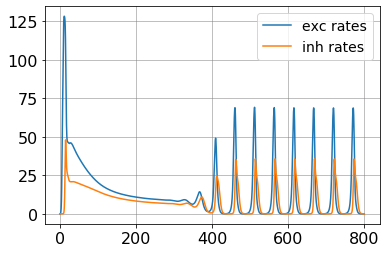

In [4]:
set_params_fast()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

fast_osc_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        fast_osc_init[i] = aln.state[state_vars[i]][0]
    else:
        fast_osc_init[i] = aln.state[state_vars[i]][0,-1]

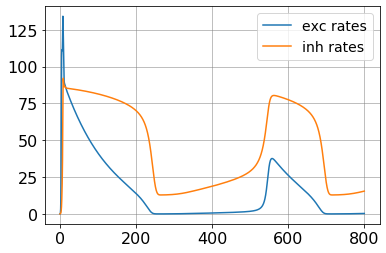

In [5]:
set_params_slow()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

slow_osc_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        slow_osc_init[i] = aln.state[state_vars[i]][0]
    else:
        slow_osc_init[i] = aln.state[state_vars[i]][0,-1]

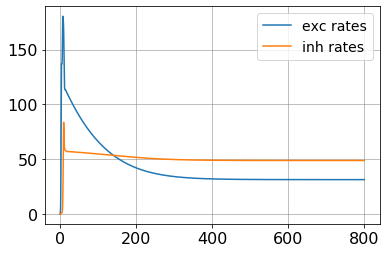

[31.3076 48.768 ]


In [6]:
set_params_up()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

up_rates = np.zeros((2))
up_rates[0] = aln.rates_exc[0,-1]
up_rates[1] = aln.rates_inh[0,-1]

print(up_rates)

up_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        up_init[i] = aln.state[state_vars[i]][0]
    else:
        up_init[i] = aln.state[state_vars[i]][0,-1]

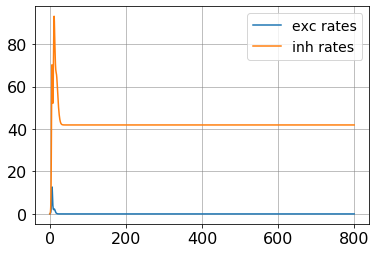

[4.4580e-10 4.1918e+01]


In [7]:
set_params_down()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

down_rates = np.zeros((2))
down_rates[0] = aln.rates_exc[0,-1]
down_rates[1] = aln.rates_inh[0,-1]

print(down_rates)

down_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        down_init[i] = aln.state[state_vars[i]][0]
    else:
        down_init[i] = aln.state[state_vars[i]][0,-1]

# A: Scenarios

scenario | control variables | precision measure
---------|--------------|-----------
A.0 | 0 | 0
B.1 | 1 | 1
B.2 | 2 | 0
B.3 | 0 | 1
B.4 | 1 | 0
B.5 | 2 | 1
B.6 | 0, 1 | 0
B.7 | 0, 1 | 1
B.8 | 0, 2 | 0
B.9 | 0, 2 | 1
B.10 | 1, 2 | 0
B.11 | 1, 2 | 1
B.12 | 0, 1, 2 | 0
B.13 | 0, 1, 2 | 1
B.14 | 0 | 0,1
B.15 | 1 | 0,1
B.16 | 2 | 0,1
B.17 | 0,1 | 0,1
B.18 | 0,2 | 0,1
B.19 | 1,2 | 0,1
B.20 | 0,1,2 | 0,1

In [8]:
max_c_c = 5.
min_c_c = - 5.
max_c_r = 0.18
min_c_r = 0.

def setmaxmincontrol(cntrl_vars):
    max_cntrl = np.zeros(( 4 ))
    min_cntrl = np.zeros(( 4 ))
    if cntrl_vars == [0]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
    elif cntrl_vars == [1]:
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
    elif cntrl_vars == [2]:
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
    elif cntrl_vars == [0,1]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
    elif cntrl_vars == [0,2]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
    elif cntrl_vars == [1,2]:
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
    elif cntrl_vars == [0,1,2]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
            
    return max_cntrl, min_cntrl        

In [9]:
dur = 600
dur_pre = 100
dur_post = 100
aln.params.duration = dur

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

set_params_fast()
setinit(fast_osc_init)

aln.run(control = aln.getZeroControl())
fast_rates = np.array( [aln.rates_exc[0,:], aln.rates_inh[0,:]] )

# set slow oscillation as target
target = aln.getZeroTarget()
target[0,0,:] = fast_rates[0,:]
target[0,1,:] = fast_rates[1,:]

In [10]:
c_var = [ [0], [1], [2], [0], [1], [2],
         [0,1], [0,1], [0,2], [0,2], [1,2], [1,2],
         [0,1,2], [0,1,2],
         [0], [1], [2], [0,1], [0,2], [1,2], [0,1,2] ]
p_var = [ [0], [1], [0], [1], [0], [1],
         [0], [1], [0], [1], [0], [1],
         [0], [1],
         [0,1], [0,1], [0,1], [0,1], [0,1], [0,1], [0,1] ]

max_it = 5000

set_params_down()
initVars = down_init

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

trans_time_array = [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 
                    0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5 ]

sheet = "D_a_"

## 0

set cost params
control input:  [0] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  81410.97810861089
RUN  1 , total integrated cost =  28220.93099366349
RUN  2 , total integrated cost =  8706.32167774579
RUN  3 , total integrated cost =  2942.1730867898946
RUN  4 , total integrated cost =  2055.3854158559902
RUN  5 , total integrated cost =  1758.7461694504257
RUN  6 , total integrated cost =  1592.0502502635104
RUN  7 , total integrated cost =  1470.0688329324387
RUN  8 , total integrated cost =  1370.7611869690013
RUN  9 , total integrated cost =  1288.4889763714507
RUN  10 , total integrated cost =  1217.0146462720222
RUN  11 , total integrated cost =  1156.1269947954322
RUN  12 , total integrated cost =  1098.9693667943407
RUN  13 , total integrated cost =  1052.3125832533897
RUN  14 , total integrated cost =  1012.967106903134
RUN  15 , total integrated cost =  978.9255538756918
RUN  16 , total integrated cost =  949.6227338166051

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  5000 , total integrated cost =  22.98316590463019
RUN  5000 , total integrated cost =  22.98316590463019
Improved over  5000  iterations by  99.97176895986439  percent.
Problem in initial value trasfer:  Vmean_exc -80.81091189200119 -80.81091170625069
Problem in initial value trasfer:  Vmean_exc -56.72811595871975 -56.75798610843452


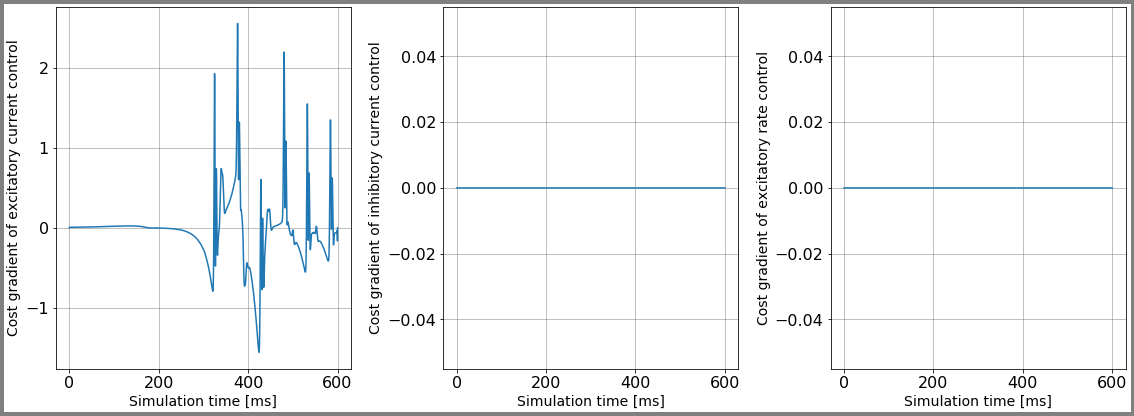

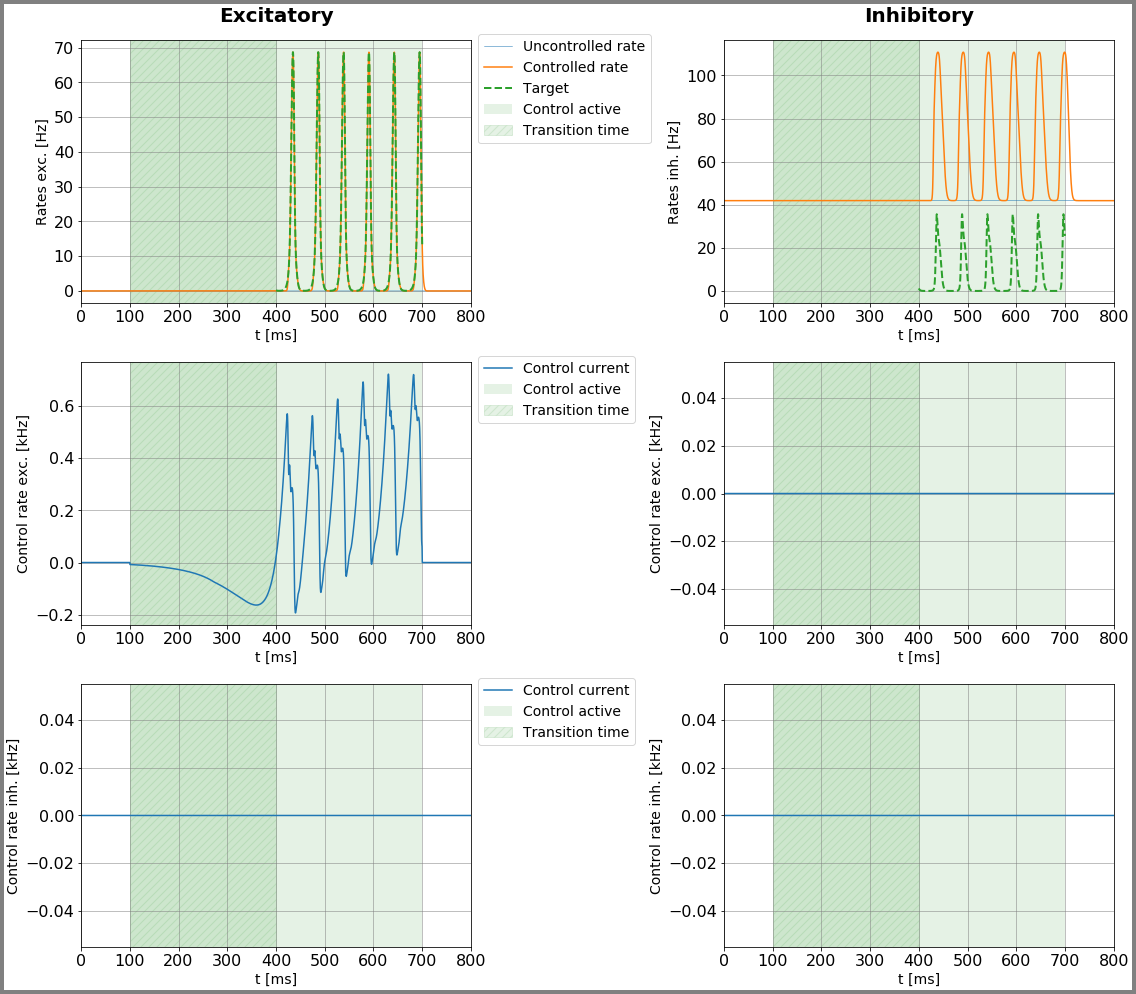

In [11]:
case_ind = 0
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  81410.97810861089
RUN  1 , total integrated cost =  28220.931610818472
RUN  2 , total integrated cost =  8706.32229481708
RUN  3 , total integrated cost =  2942.1736793861833
RUN  4 , total integrated cost =  2055.3860040376558
RUN  5 , total integrated cost =  1758.7467582346965
RUN  6 , total integrated cost =  1592.0508373578618
RUN  7 , total integrated cost =  1470.06941868481
RUN  8 , total integrated cost =  1370.7617730016482
RUN  9 , total integrated cost =  1288.489561107307
RUN  10 , total integrated cost =  1217.0152334724692
RUN  11 , total integrated cost =  1156.1275790690697
RUN  12 , total integrated cost =  1098.9699523534716
RUN  13 , total integrated cost =  1052.3131666391146
RUN  14 , total integrated cost =  1012.9676909575659
RUN  15 , total integrated cost =  978.9261365296228
RUN  16 , total integrated cost =  949.6233172514089
RUN  17 , total integrated cost =  923.1875817

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  5000 , total integrated cost =  23.075887207737956
RUN  5000 , total integrated cost =  23.075887207737956
Improved over  5000  iterations by  99.97165506698992  percent.
Problem in initial value trasfer:  Vmean_exc -80.81091189200119 -80.81091170625069
Problem in initial value trasfer:  Vmean_exc -56.728130665153856 -56.75799867570922


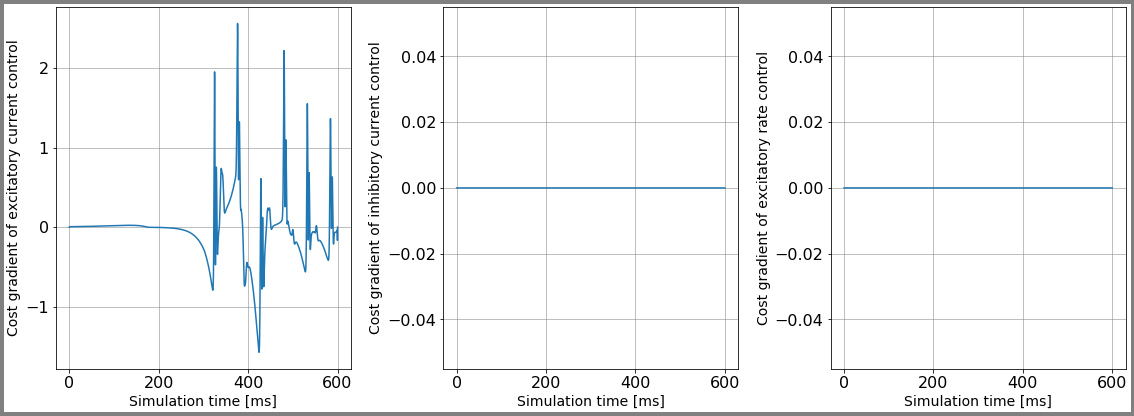

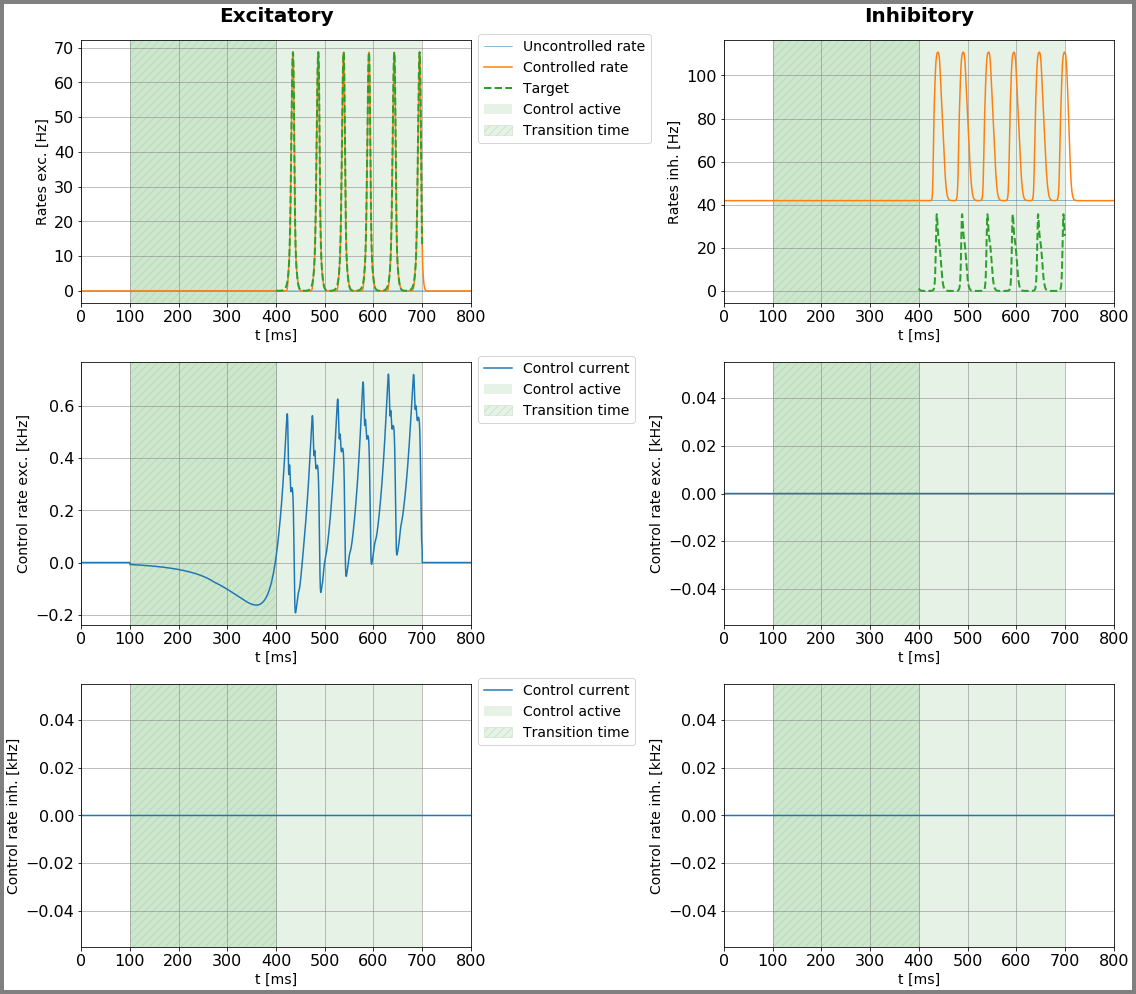

In [12]:
# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case_ind = 0
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 1e-6, 1e-6)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 2

set cost params
control input:  [2] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  81410.97810861089
RUN  1 , total integrated cost =  64972.81511331574
RUN  2 , total integrated cost =  64230.5552078392
RUN  3 , total integrated cost =  64080.889351701946
RUN  4 , total integrated cost =  63448.13684818433
RUN  5 , total integrated cost =  63379.88756363284
RUN  6 , total integrated cost =  63002.985612556535
RUN  7 , total integrated cost =  62861.65628926248
RUN  8 , total integrated cost =  62638.754078799815
RUN  9 , total integrated cost =  62611.77808737385
RUN  10 , total integrated cost =  62073.71197074735
RUN  11 , total integrated cost =  62064.122485859516
RUN  12 , total integrated cost =  62052.66194511501
RUN  13 , total integrated cost =  62018.51398505066
RUN  14 , total integrated cost =  62009.64466176901
RUN  15 , total integrated cost =  62003.60145680947
RUN  16 , total integrated cost =  61993.50470385906
RUN  1

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  97 , total integrated cost =  61930.95948929683
Improved over  97  iterations by  23.927999726677697  percent.
Problem in initial value trasfer:  Vmean_exc -80.81091189200119 -80.81091170625069
Problem in initial value trasfer:  Vmean_exc -60.29193357923447 -60.320055438837144


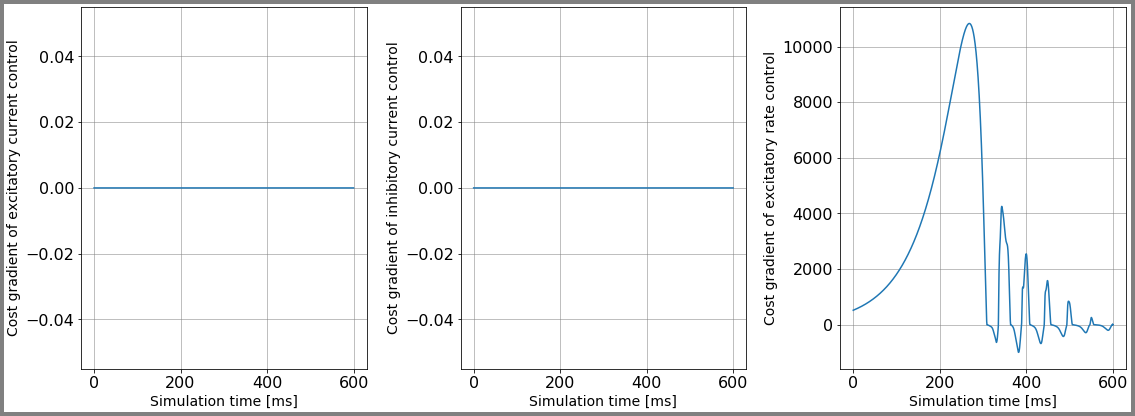

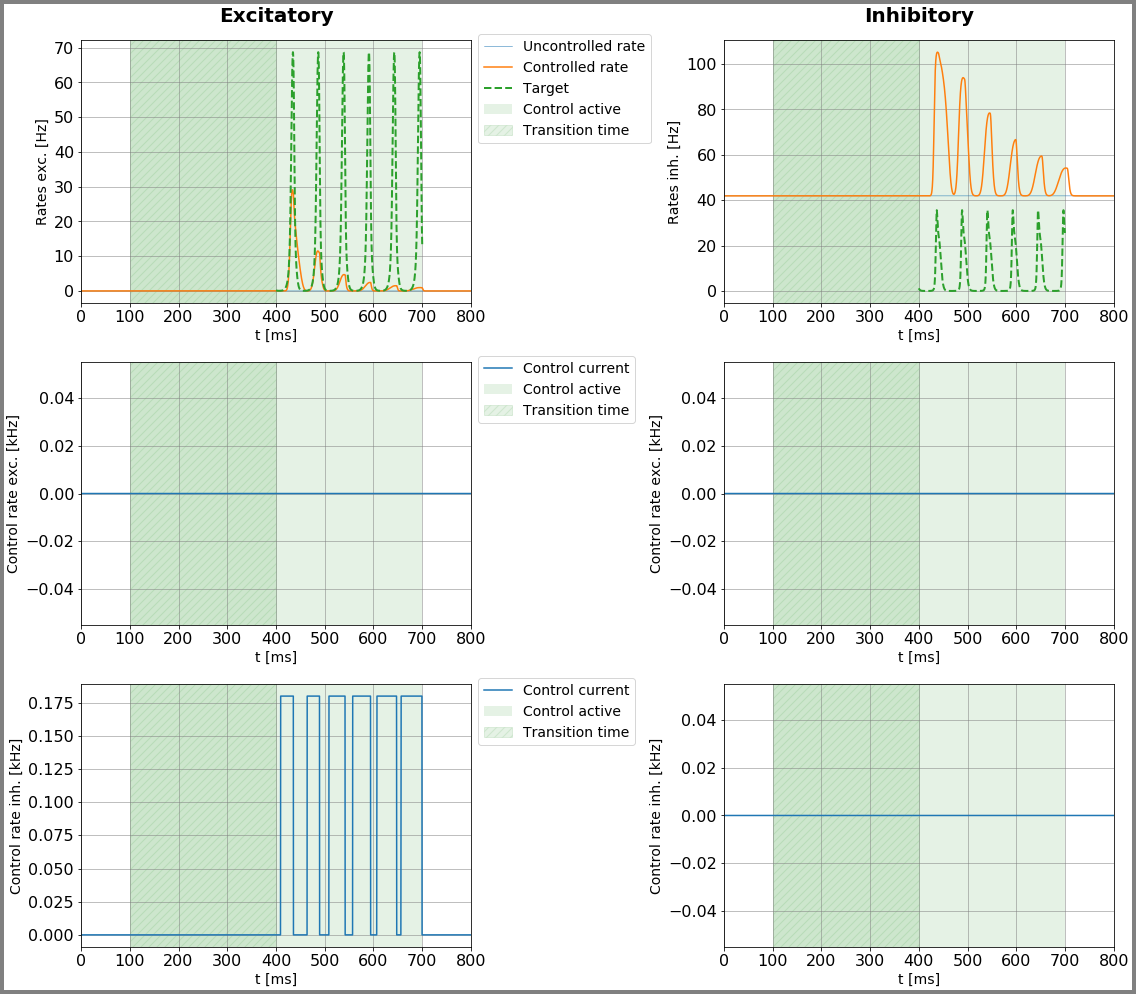

In [13]:
case_ind = 2
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

In [ ]:
case_ind = 2
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 1e-2, 1e-2)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 4

set cost params
control input:  [1] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  81410.97810861089


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  81410.97810861089
Control only changes marginally.
RUN  1 , total integrated cost =  81410.97810861089
Improved over  1  iterations by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -80.81091189200119 -80.81091170625069


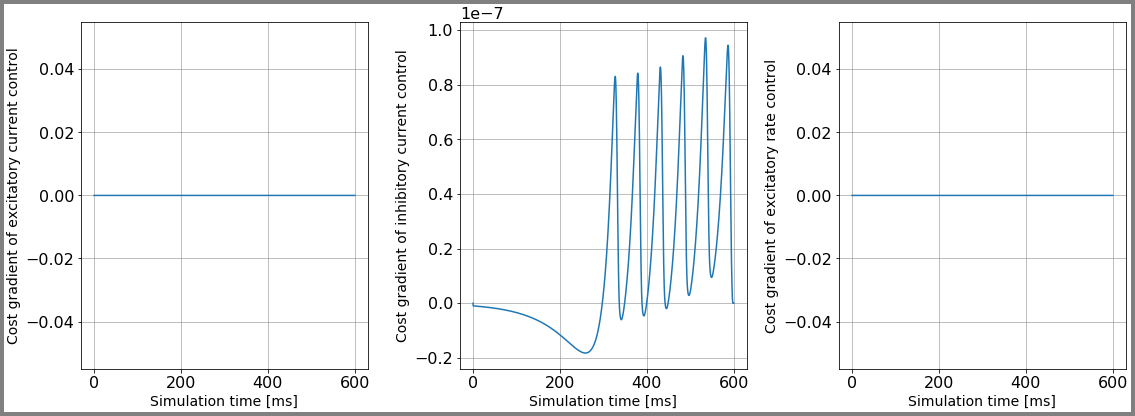

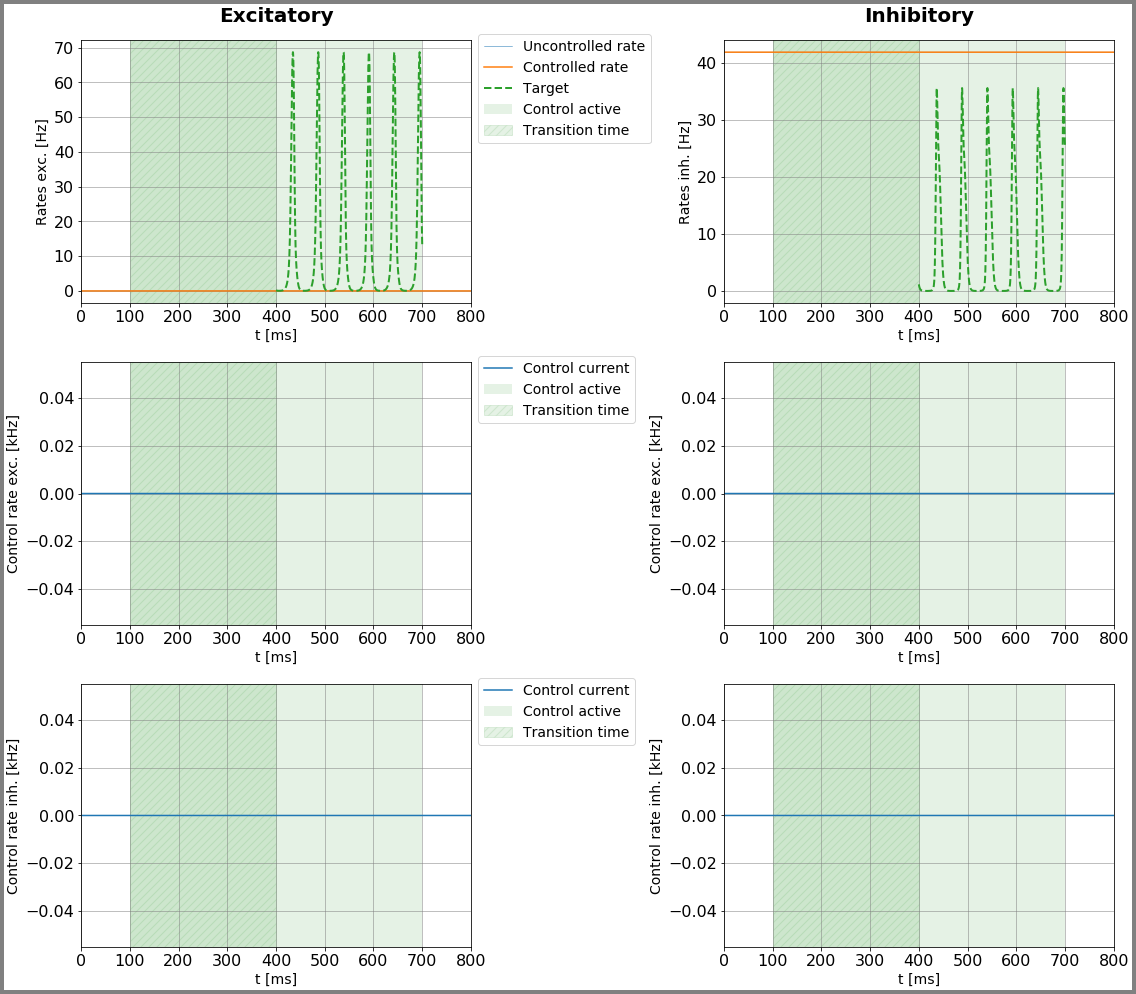

In [15]:
# A.4.a)

case_ind = 4
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  81410.97810861089


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  81410.97810861089
Control only changes marginally.
RUN  1 , total integrated cost =  81410.97810861089
Improved over  1  iterations by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -80.81091189200119 -80.81091170625069


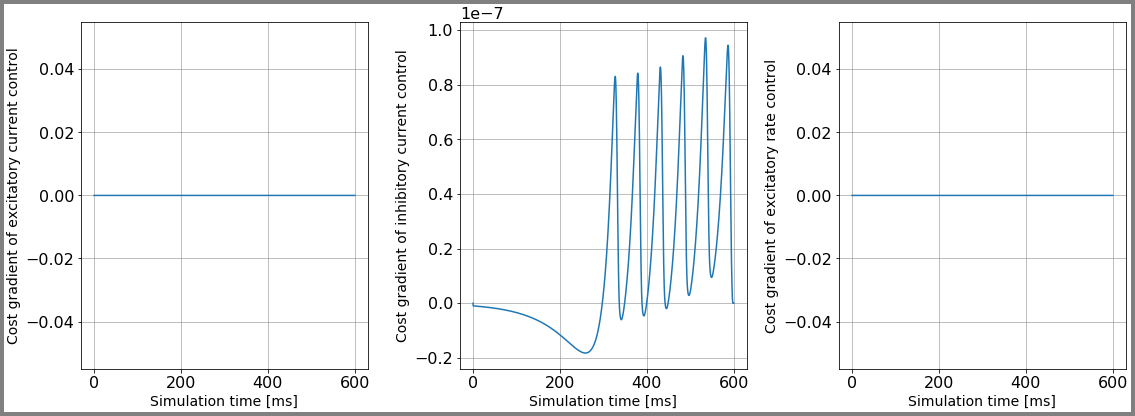

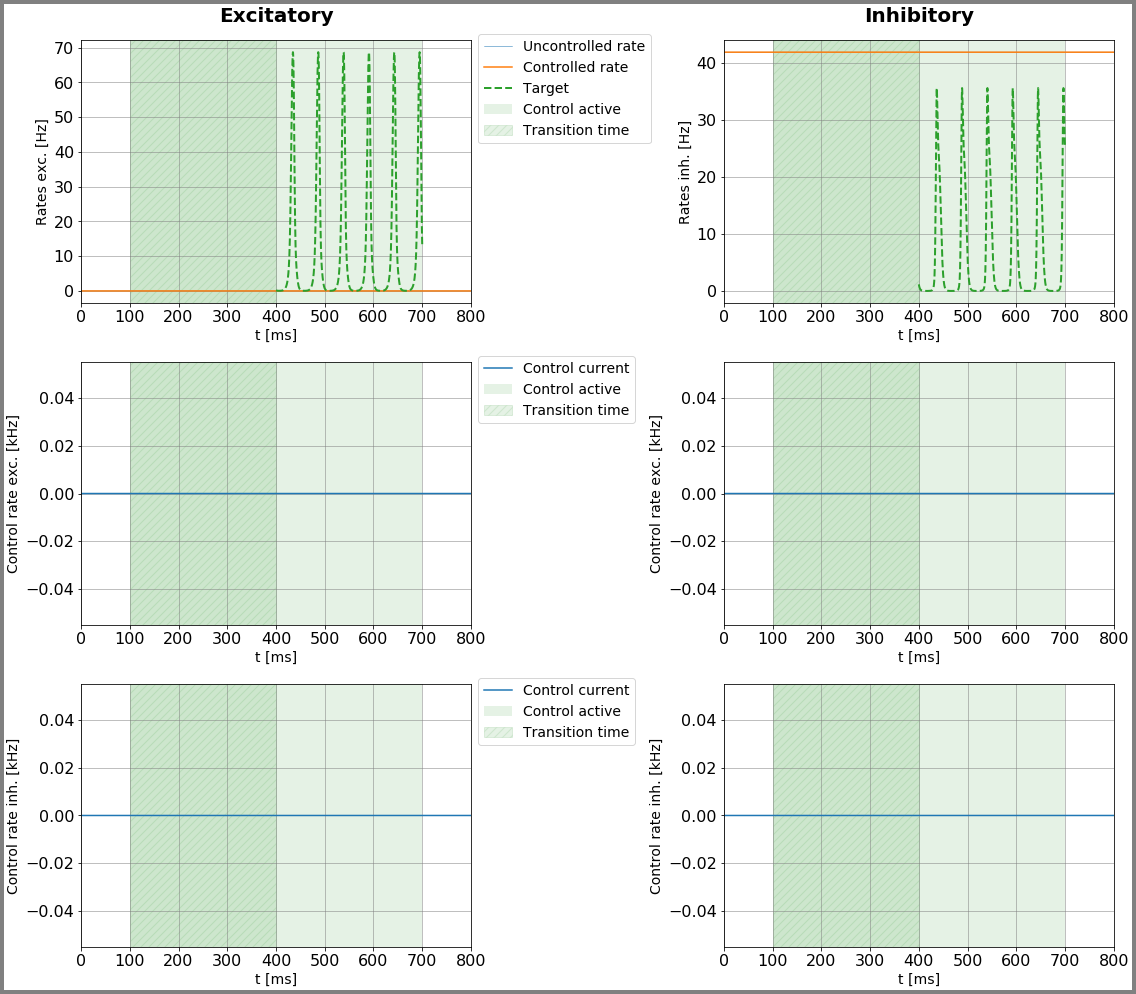

In [16]:
case_ind = 4
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 6

set cost params
control input:  [0, 1] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  81410.97810861089
RUN  1 , total integrated cost =  21983.874799367484
RUN  2 , total integrated cost =  7521.395657477221
RUN  3 , total integrated cost =  3000.1950760672994
RUN  4 , total integrated cost =  2398.4540849736068
RUN  5 , total integrated cost =  2093.9045307313604
RUN  6 , total integrated cost =  1893.9028668136145
RUN  7 , total integrated cost =  1739.4752818260592
RUN  8 , total integrated cost =  1616.7275323724282
RUN  9 , total integrated cost =  1515.6659146588652
RUN  10 , total integrated cost =  1433.7212964772168
RUN  11 , total integrated cost =  1361.9978354971074
RUN  12 , total integrated cost =  1302.896992915207
RUN  13 , total integrated cost =  1252.5014826811746
RUN  14 , total integrated cost =  1207.2583327938478
RUN  15 , total integrated cost =  1166.9362290688591
RUN  16 , total integrated cost =  1130.572323

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  5000 , total integrated cost =  20.384383134624464
RUN  5000 , total integrated cost =  20.384383134624464
Improved over  5000  iterations by  99.97496113717314  percent.
Problem in initial value trasfer:  Vmean_exc -80.81091189200119 -80.81091170625069
Problem in initial value trasfer:  Vmean_exc -56.72716827902631 -56.75674073080822


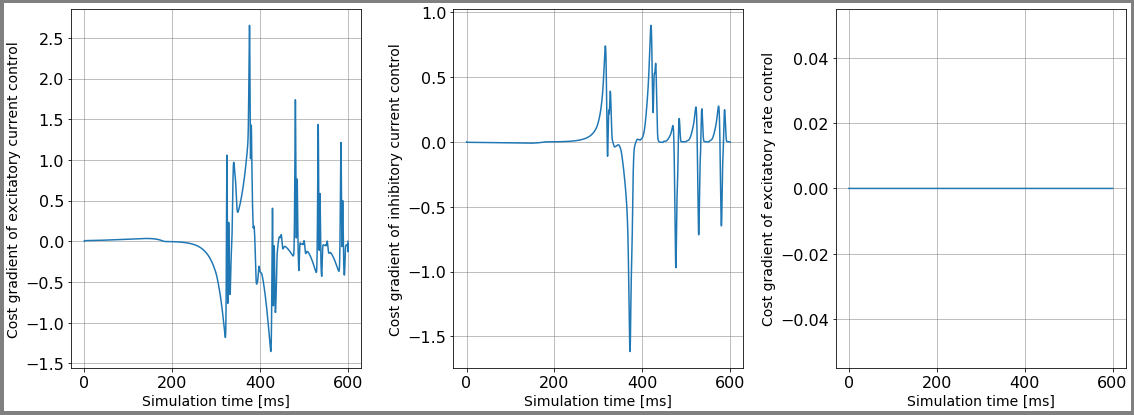

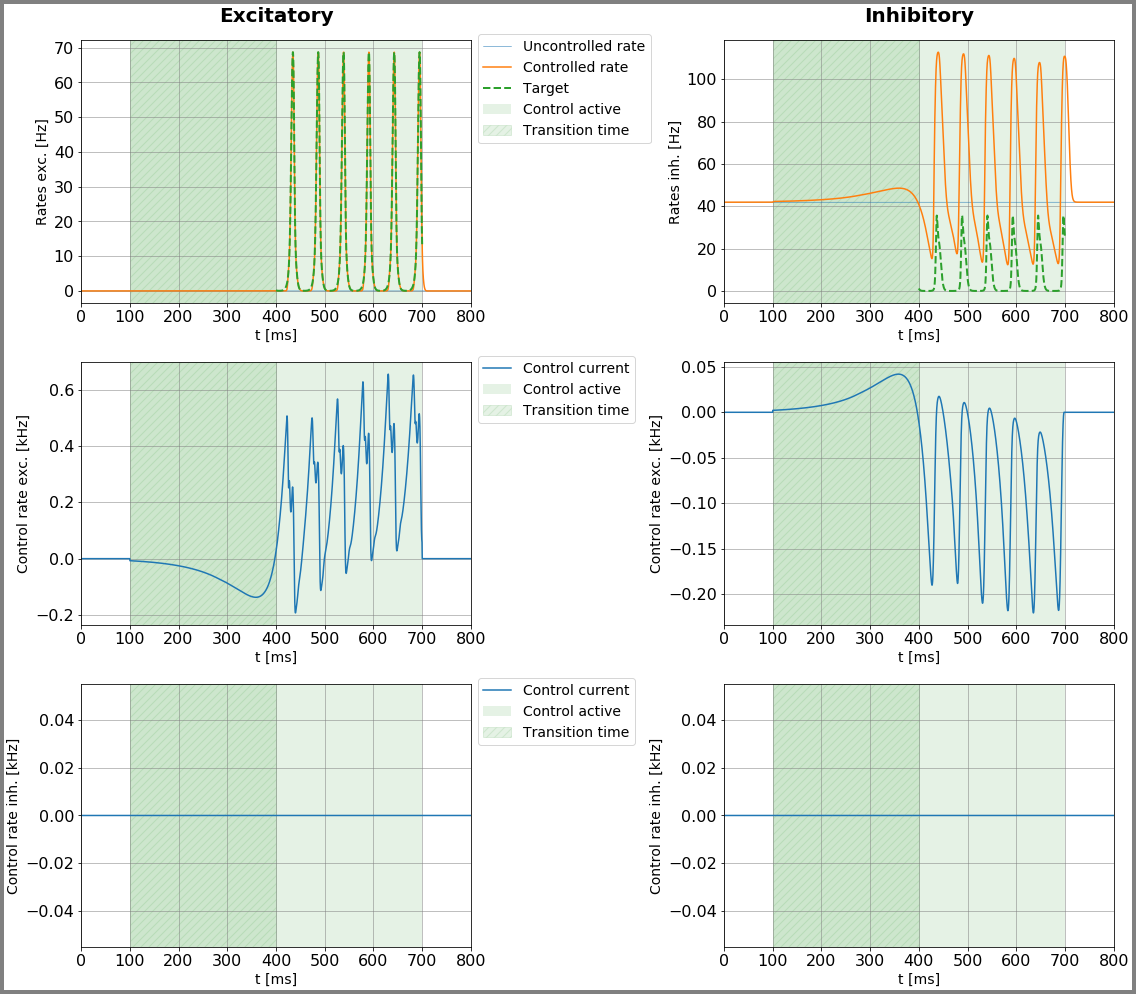

In [17]:
# A.6.a)
case_ind = 6
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  81410.97810861089


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  81410.97810861089
Control only changes marginally.
RUN  1 , total integrated cost =  81410.97810861089
Improved over  1  iterations by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -80.81091189200119 -80.81091170625069


D:\Promotion\neurolib\neurolib\utils\plotFunctions.py:47: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax[1,2].set_yscale('log')


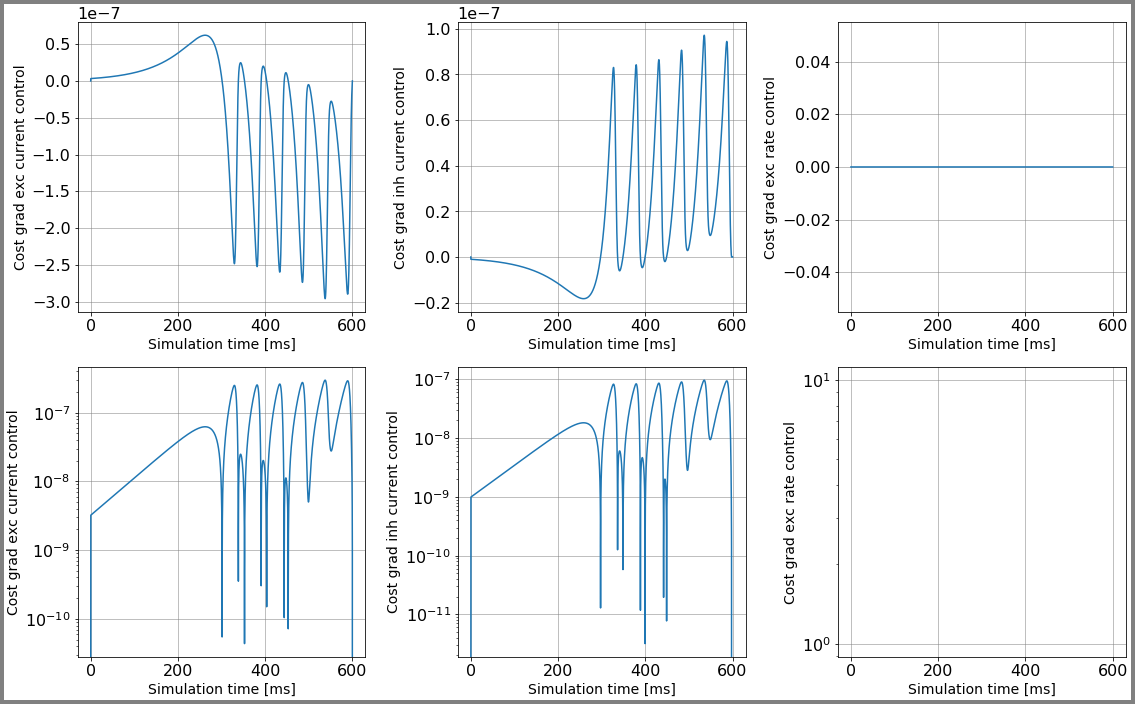

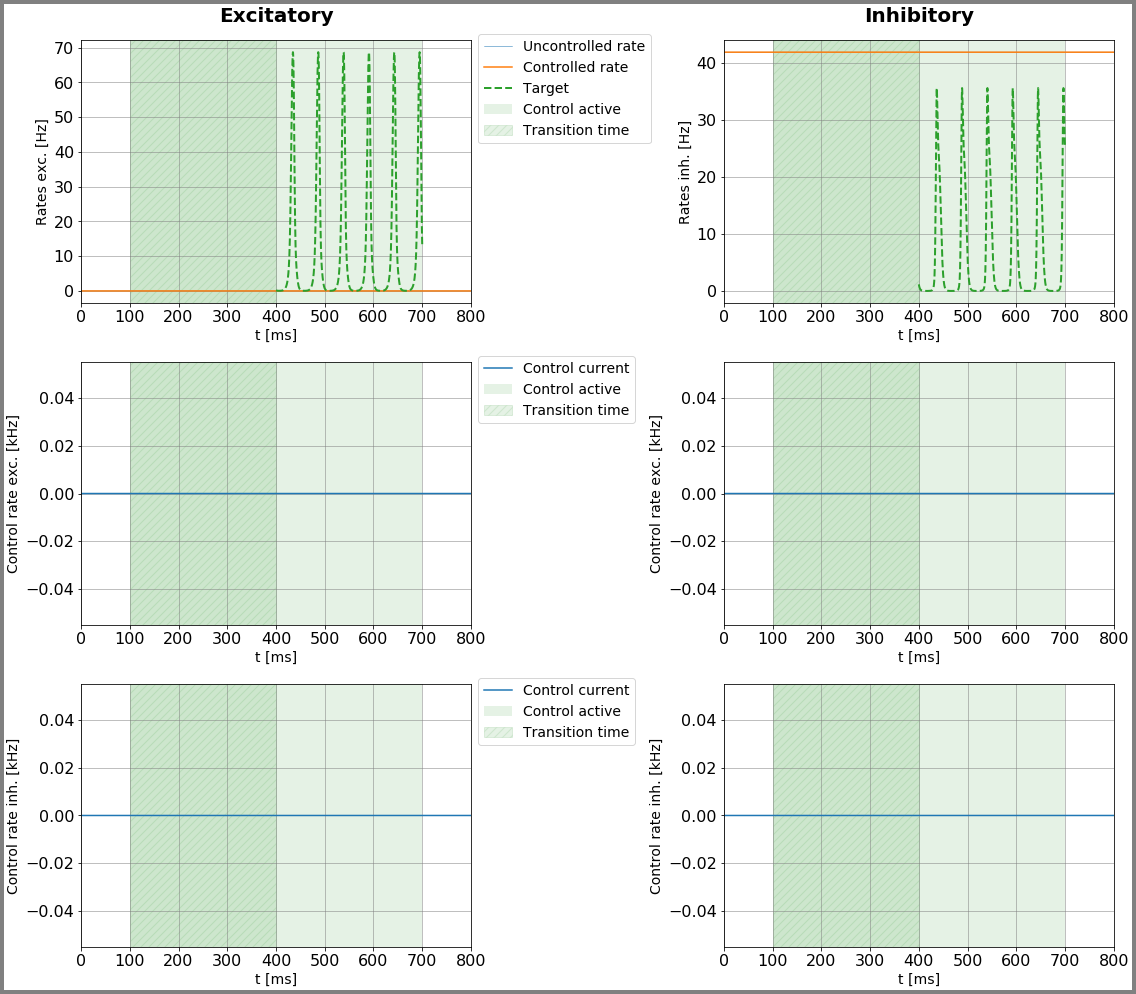

In [18]:
case_ind = 6
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 1e-5, 1e-5)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 8

set cost params
control input:  [0, 2] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  81410.97810861089
RUN  1 , total integrated cost =  28220.93099366349
RUN  2 , total integrated cost =  8706.32167774579
RUN  3 , total integrated cost =  2942.1730867898946
RUN  4 , total integrated cost =  2055.3854158559902
RUN  5 , total integrated cost =  1758.7461694504257
RUN  6 , total integrated cost =  1592.0502502635104
RUN  7 , total integrated cost =  1470.0688329324387
RUN  8 , total integrated cost =  1370.7611869690013
RUN  9 , total integrated cost =  1288.4889763714507
RUN  10 , total integrated cost =  1217.0146462720222
RUN  11 , total integrated cost =  1156.1269947954322
RUN  12 , total integrated cost =  1098.9693667943407
RUN  13 , total integrated cost =  1052.3125832533897
RUN  14 , total integrated cost =  1012.967106903134
RUN  15 , total integrated cost =  978.9255538756918
RUN  16 , total integrated cost =  949.6227338166

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  5000 , total integrated cost =  22.98316590463019
RUN  5000 , total integrated cost =  22.98316590463019
Improved over  5000  iterations by  99.97176895986439  percent.
Problem in initial value trasfer:  Vmean_exc -80.81091189200119 -80.81091170625069
Problem in initial value trasfer:  Vmean_exc -56.72811595871975 -56.75798610843452


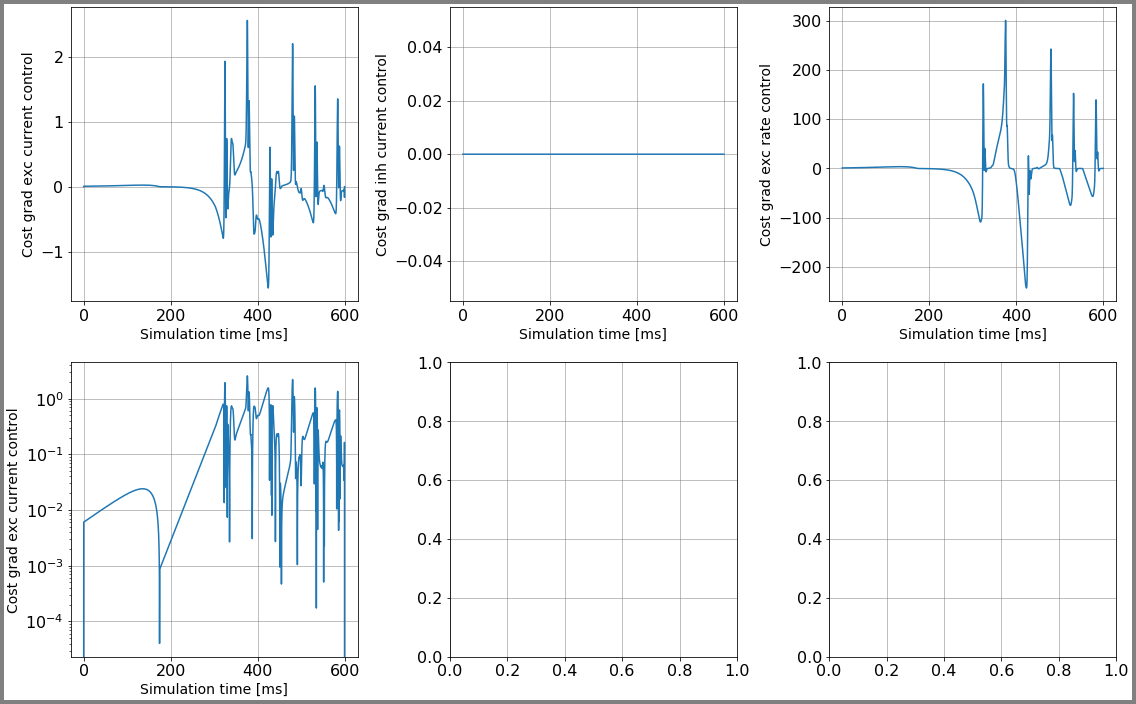

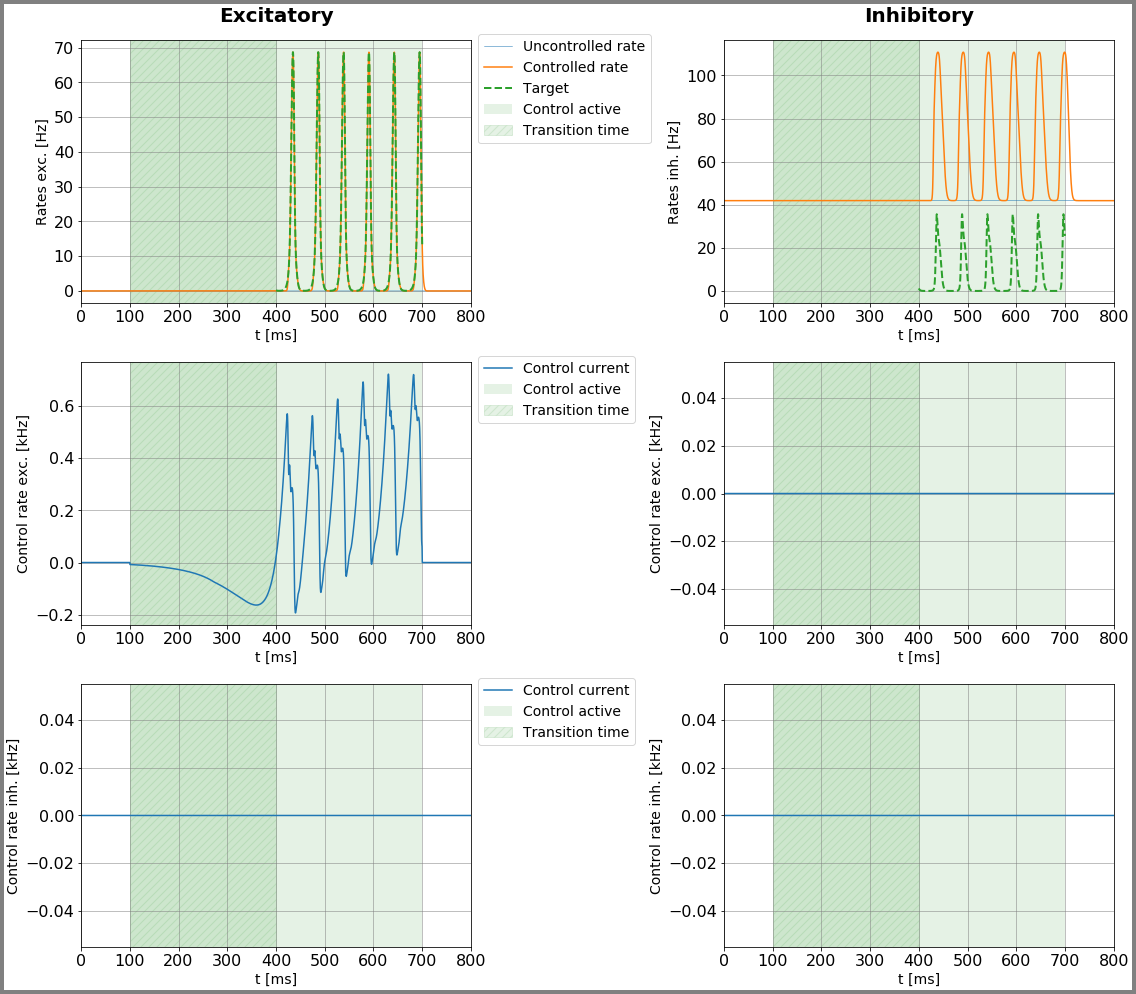

In [19]:
# A.8.a)
case_ind = 8
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  81410.97810861089
RUN  1 , total integrated cost =  64943.19587847938
RUN  2 , total integrated cost =  46295.61370022929
RUN  3 , total integrated cost =  31667.822312212378
RUN  4 , total integrated cost =  18080.37507179515
RUN  5 , total integrated cost =  8362.583758010735
RUN  6 , total integrated cost =  3103.1177937073044
RUN  7 , total integrated cost =  1216.1845020057
RUN  8 , total integrated cost =  647.8883295147992
RUN  9 , total integrated cost =  396.9795682435188
RUN  10 , total integrated cost =  280.2137420097986
RUN  11 , total integrated cost =  216.6694872382254
RUN  12 , total integrated cost =  178.98564760920206
RUN  13 , total integrated cost =  155.23554373494784
RUN  14 , total integrated cost =  138.94779045485961
RUN  15 , total integrated cost =  125.84435733947704
RUN  16 , total integrated cost =  115.47869698091762
RUN  17 , total integrated cost =  107.23632831498

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  5000 , total integrated cost =  0.3477773253024112
RUN  5000 , total integrated cost =  0.3477773253024112
Improved over  5000  iterations by  99.99957281274175  percent.
Problem in initial value trasfer:  Vmean_exc -80.81091189200119 -80.81091170625069
Problem in initial value trasfer:  Vmean_exc -56.72298650270497 -56.75664270807232


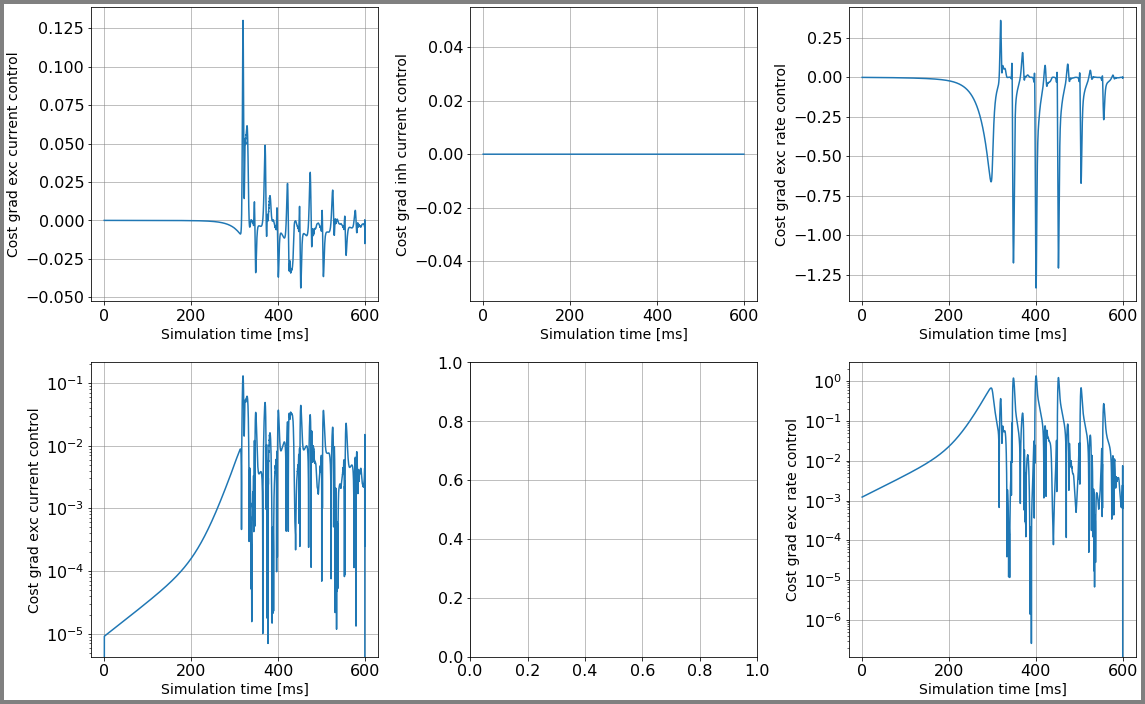

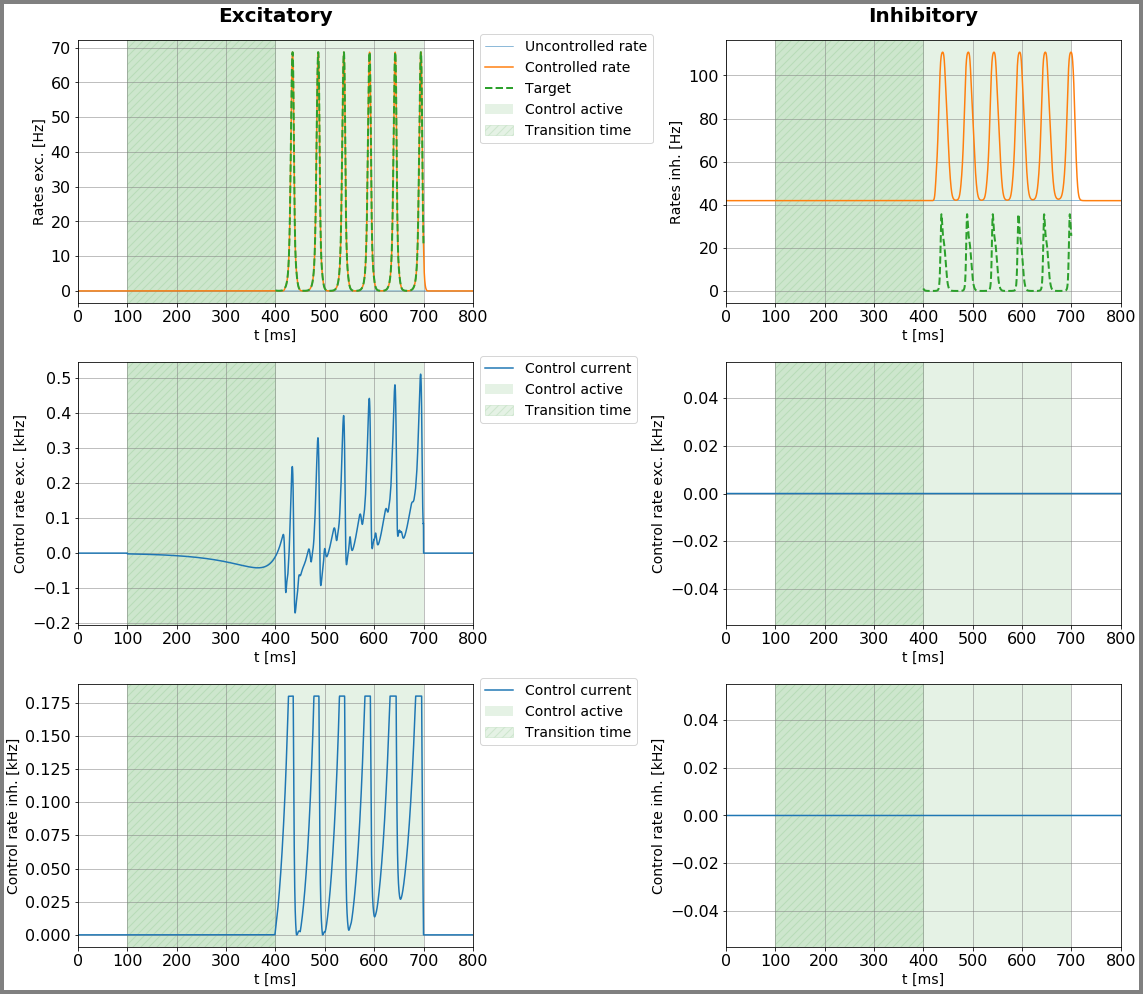

In [20]:
case_ind = 8
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 1e-4, 1e-4)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 10

In [ ]:
# A.10.a)
case_ind = 10
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
control input:  [1, 2] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  81410.97810861089
RUN  1 , total integrated cost =  64970.88204081282
RUN  2 , total integrated cost =  44808.21369623565
RUN  3 , total integrated cost =  36377.23869707592
RUN  4 , total integrated cost =  20754.182100419443
RUN  5 , total integrated cost =  6880.744105666618
RUN  6 , total integrated cost =  4798.169827628526
RUN  7 , total integrated cost =  4104.125763132695
RUN  8 , total integrated cost =  3342.5597037780067
RUN  9 , total integrated cost =  3136.306147146864
RUN  10 , total integrated cost =  2984.6122150528945
RUN  11 , total integrated cost =  2850.81482858041
RUN  12 , total integrated cost =  2717.307964252664
RUN  13 , total integrated cost =  2602.412984883199
RUN  14 , total integrated cost =  2486.8845144414813
RUN  15 , total integrated cost =  2380.57746095132
RUN  16 , total integrated cost =  2214.3614426585377
RUN

In [ ]:
case_ind = 10
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 1e-4, 1e-4)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 12

In [ ]:
# A.12.a)
case_ind = 12
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

In [ ]:
case_ind = 12
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 1e-4, 1e-4)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )